In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain.chat_models import init_chat_model
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import tools_condition, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

from langgraph.graph import START, END, StateGraph
# llm= init_chat_model(
#     model="qwen3.6", 
#     model_provider="ollama",
#     temperature=0.3
# )


memory = MemorySaver()

class State(TypedDict):
    messages: Annotated[list, add_messages]

#define tool here 
@tool("get_stock_price", description="Fetches the stock price for a given stock symbol")
def get_stock_price(stock_symbol: str) -> float:
    ''' Placeholder implementation for fetching stock price
        :param stock_symbol: The stock symbol to fetch the price for
        :return: The stock price as a float
    '''
    stock_prices = {
        "AAPL": 150.0,
        "GOOGL": 2800.0,
        "AMZN": 3400.0,
        "MSFT": 300.0
    }
    return stock_prices.get(stock_symbol.upper(), 0.0)

@tool("buy_stocks", description="Buy stocks for a given stock symbol and quantity")
def buy_stocks(stock_symbol: str, quantity: int, total_cost: float) -> float:
    ''' Placeholder implementation for buying stocks
        :param stock_symbol: The stock symbol to buy
        :param quantity: The number of shares to buy
        :param total_cost: The total cost of the purchase
        :return: The total cost of the purchase
    '''
    decision = interrupt("Do you want to proceed with the purchase? (yes/no)")
    if decision.lower() != "yes":
        return "Purchase cancelled."    
    else:
        return f"Successfully bought {quantity} shares of {stock_symbol} for a total cost of ${total_cost:.2f}"

#prepare tools list available for chatbot to use
tools = [get_stock_price, buy_stocks]

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.7
)

#llm with tools binding
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
#add tool node
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
#add conditional edge to tool node
builder.add_conditional_edges("chatbot_node", tools_condition)
builder.add_edge("tools", "chatbot_node")
builder.add_edge("chatbot_node", END)
graph = builder.compile(checkpointer=memory)




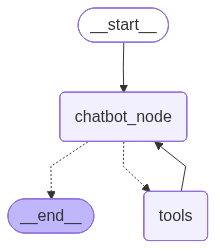

In [12]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {'configurable':{'thread_id':'trade_thread'}}
message = {"role": "user", "content": "get price of 10 stocks of AAPL and 10 stocks of GOOGL, what is the total price?"}
state = graph.invoke({"messages": [message]}, config=config)

print(state.get("__interrupt__"))
decision = input("Do you want to proceed with the purchase? (yes/no): ")
graph.invoke(Command(resume=decision), config=config)

[Interrupt(value='Do you want to proceed with the purchase? (yes/no)', id='b9cdeac3a37359d225bc5ec8d9d1d598')]


In [13]:

message = {"role": "user", "content": "Buy 10 stocks of AAPL."}
state = graph.invoke({"messages": [message]}, config=config)

print(state["messages"][-1].content)